<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 05</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Feature engineering</div><div style="font-size:1.05em;opacity:0.85">What we know about a customer at the cutoff — and nothing more.</div></div>

Stage 04 fixed *what* we predict; this stage fixes *what the model may know* when it predicts.
Every feature is computed from transactions dated on or before the cutoff. The groups follow one
rule each: **base** features summarise history and are what a user may edit in the what-if;
**derived** features are arithmetic on base features, so the browser can recompute them
exactly; **context** features describe the cutoff (the season), not the customer.

**Pipeline rule.** The definitions live in `churnvalue.features` and are documented once in
`FEATURE_CATALOGUE`. Every statistic that looks at the label here uses **training cutoffs
only**: effect sizes are context for reading the model later, never a selection rule.

| | |
|---|---|
| **Input** | `data/interim/transactions.parquet` · `data/interim/snapshots.parquet` |
| **Outputs** | `reports/results/05_summary.json` · `reports/figures/05_*.png` |
| **Parameters** | `configs/default.yaml` → `snapshots`, `splits` |
| **Shared code** | `churnvalue.features` (catalogue, feature functions) · `churnvalue.stats` (Cliff's δ) · `churnvalue.splits` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">F1 catalogue</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">F2 leakage guard</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">F3 distributions</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">F4 effect sizes</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">F5 redundancy</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">F6 the season</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.cluster import hierarchy

from churnvalue.config import load_config, project_root
from churnvalue.features import (
    BASE_FEATURES,
    CONTEXT_FEATURES,
    DERIVED_FEATURES,
    FEATURE_CATALOGUE,
    add_derived_features,
    compute_base_features,
)
from churnvalue.reporting import StageSummary
from churnvalue.snapshots import make_cutoffs
from churnvalue.splits import make_temporal_split
from churnvalue.stats import cliffs_band, cliffs_delta
from churnvalue.viz import style
from churnvalue.viz.style import CHURN, DIVERGING, INK, MUTED, NEUTRAL, RETAINED

os.chdir(project_root())
CFG = load_config()
SNAP = CFG.snapshots
H = SNAP.horizon_days
STAGE, FIGURES, RESULTS = "05", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


tx = pd.read_parquet(CFG.data.interim_dir / "transactions.parquet")
snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
cutoffs = make_cutoffs(tx["date"].min(), tx["date"].max(), H, SNAP.min_history_months)
split = make_temporal_split(cutoffs, H, CFG.splits.calibration_offset_months)
train = snapshots[snapshots["cutoff"].isin(split.train)]
MODEL_FEATURES = BASE_FEATURES + DERIVED_FEATURES + CONTEXT_FEATURES
S["n_features"] = {
    "base": len(BASE_FEATURES),
    "derived": len(DERIVED_FEATURES),
    "context": len(CONTEXT_FEATURES),
}
S["train_rows"] = len(train)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">F1 · Catalogue</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">nineteen features, three groups, one source of truth</span></div>

In [2]:
catalogue = pd.DataFrame(
    [
        {
            "feature": name,
            "group": info.group,
            "unit": info.unit,
            "definition": info.description,
            "what-if": "editable"
            if info.editable
            else "recomputed"
            if info.group == "derived"
            else "fixed",
        }
        for name, info in FEATURE_CATALOGUE.items()
    ]
)
display(catalogue.style.hide(axis="index"))

feature,group,unit,definition,what-if
recency_days,base,days,days since the last purchase day,editable
n_purchase_days,base,days,distinct days with a purchase,editable
tenure_days,base,days,days since the first purchase day,editable
total_spend,base,£,gross spend on purchase days,editable
avg_order_value,base,£,gross spend per purchase day,editable
n_distinct_products,base,count,distinct stock codes bought,editable
return_rate,base,share,"returned value / gross spend, in [0, 1]",editable
spend_90d,base,£,spend in the 90 days before the cutoff,editable
spend_prev_90d,base,£,spend in the 90 days before those,editable
purchases_90d,base,days,purchase days in the last 90 days,editable


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">F2 · Leakage guard</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the future is changed, the features are not</span></div>

The unit tests prove this property on synthetic data (`tests/test_leakage.py`, a hypothesis
property test). Here it is shown on the real data: every transaction after the test cutoff is
shifted a month later, its value tripled, and half of those rows deleted. The features at the
cutoff must not move by a single penny or day.

In [3]:
t = split.test
future = tx["date"] > t
rng = np.random.default_rng(CFG.evaluation.seed)
scrambled = tx.copy()
scrambled.loc[future, "date"] += pd.Timedelta(days=30)
scrambled.loc[future, "revenue"] *= 3
scrambled = scrambled.loc[~(future & (rng.random(len(tx)) < 0.5))]


def features_at(frame, cutoff):
    return add_derived_features(compute_base_features(frame, cutoff, H), H, SNAP.cadence_floor_days)


original, mutated = features_at(tx, t), features_at(scrambled, t)
diff = original[BASE_FEATURES + DERIVED_FEATURES] - mutated[BASE_FEATURES + DERIVED_FEATURES]
S["future_rows_changed"] = int(future.sum())
S["max_abs_feature_change"] = float(diff.abs().to_numpy().max())
assert S["max_abs_feature_change"] == 0.0
print(
    f"{S['future_rows_changed']:,} future rows scrambled -> "
    f"largest change in any feature of any customer: {S['max_abs_feature_change']}"
)

160,803 future rows scrambled -> largest change in any feature of any customer: 0.0


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">F3 · Distributions by class</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">training cutoffs only, churners in red</span></div>

Small multiples with the same layout, so the eye compares shapes. Skewed money and count
features are drawn on a log scale (with +1 so zero survives). Densities are normalised per class:
the classes are close to balanced (39 % churn in training), but shape is what matters here.

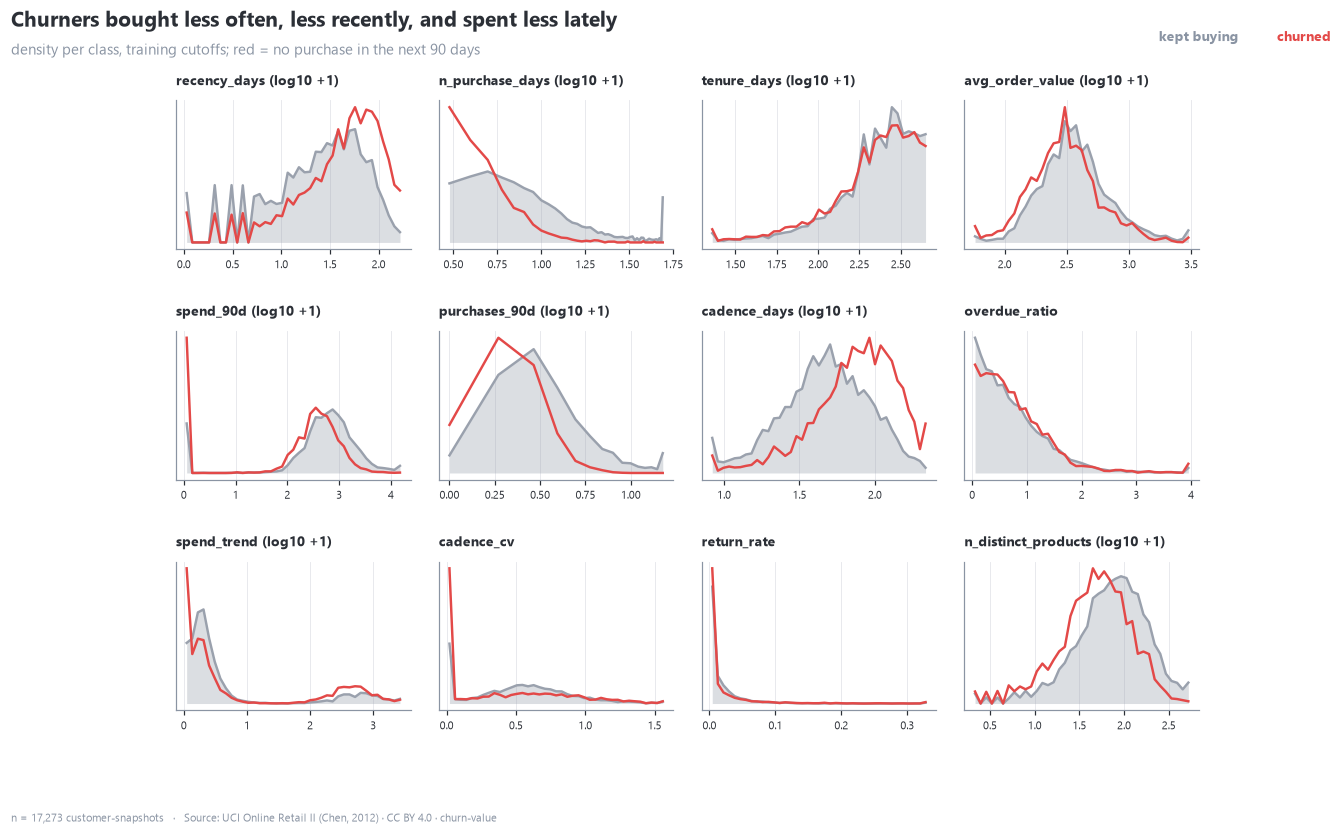

In [4]:
panels = [
    "recency_days",
    "n_purchase_days",
    "tenure_days",
    "avg_order_value",
    "spend_90d",
    "purchases_90d",
    "cadence_days",
    "overdue_ratio",
    "spend_trend",
    "cadence_cv",
    "return_rate",
    "n_distinct_products",
]
logged = {
    "n_purchase_days",
    "tenure_days",
    "avg_order_value",
    "spend_90d",
    "purchases_90d",
    "cadence_days",
    "spend_trend",
    "n_distinct_products",
    "recency_days",
}
fig, axes = plt.subplots(3, 4, figsize=(12, 7.2))
for ax, name in zip(axes.ravel(), panels, strict=True):
    values = np.log10(train[name] + 1) if name in logged else train[name]
    lo, hi = np.nanpercentile(values, [0.5, 99.5])
    support = np.unique(values[(values >= lo) & (values <= hi)])
    if len(support) < 60:  # integer-valued: one bin per value, not empty bins between them
        mids = (support[:-1] + support[1:]) / 2
        first, last = support[0] - (mids[0] - support[0]), support[-1] + (support[-1] - mids[-1])
        bins = np.r_[first, mids, last]
    else:
        bins = np.linspace(lo, hi, 40)
    for label, color, fill in [(0, RETAINED, 0.35), (1, CHURN, 0.0)]:
        part = values[train["churn"] == label]
        density, edges = np.histogram(part.clip(lo, hi), bins=bins, density=True)
        centers = (edges[:-1] + edges[1:]) / 2
        if fill:
            ax.fill_between(centers, density, color=color, alpha=fill, lw=0)
        ax.plot(centers, density, color=color, lw=1.6)
    ax.set_title(name + (" (log10 +1)" if name in logged else ""), fontsize=9)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="x", labelsize=7.5)
fig.subplots_adjust(hspace=0.55, wspace=0.12)
fig.text(
    1.0,
    axes[0, 0].get_position().y1 + 0.075,
    "churned",
    color=CHURN,
    fontsize=9,
    fontweight="bold",
    ha="right",
    transform=fig.transFigure,
)
fig.text(
    0.93,
    axes[0, 0].get_position().y1 + 0.075,
    "kept buying",
    color=MUTED,
    fontsize=9,
    fontweight="bold",
    ha="right",
    transform=fig.transFigure,
)
style.headline(
    fig,
    "Churners bought less often, less recently, and spent less lately",
    "density per class, training cutoffs; red = no purchase in the next 90 days",
)
style.add_source(fig, f"n = {len(train):,} customer-snapshots")
save(fig, "distributions")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">F4 · Effect sizes</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">how far apart the classes are, feature by feature</span></div>

With 17,000 rows almost any difference is statistically significant, so p-values say nothing.
Cliff's δ measures *how much* the classes differ: the probability that a random churner has a
higher value than a random non-churner, minus the reverse. Bounded in [−1, 1], rank-based, and
indifferent to skew. Bands: |δ| < 0.147 negligible · < 0.33 small · < 0.474 medium · else large.

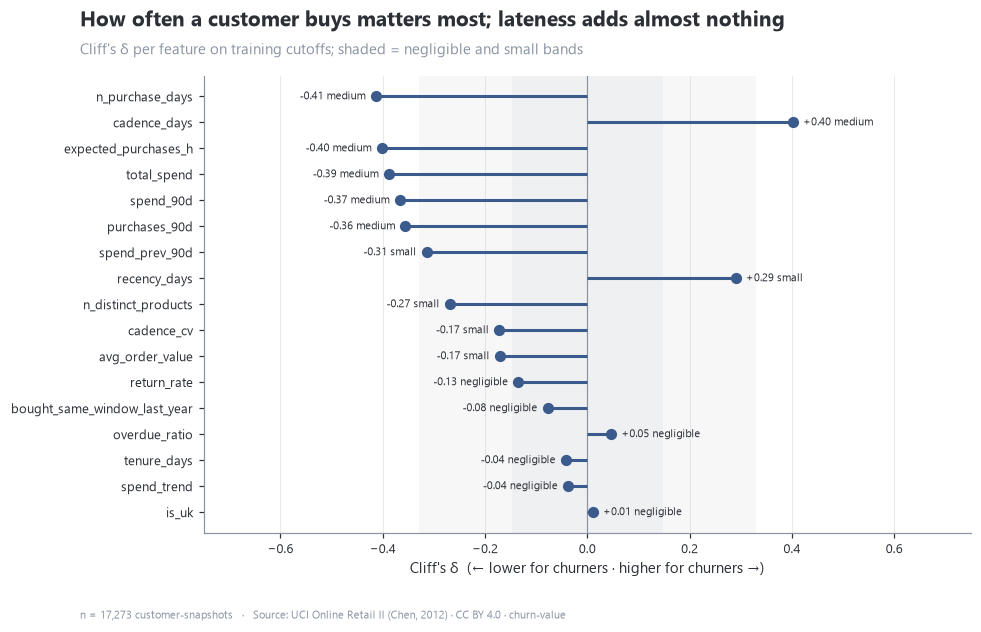

In [5]:
effects = pd.DataFrame(
    [
        {
            "feature": name,
            "delta": cliffs_delta(
                train.loc[train["churn"] == 1, name], train.loc[train["churn"] == 0, name]
            ),
        }
        for name in BASE_FEATURES + DERIVED_FEATURES
    ]
)
effects["band"] = effects["delta"].map(cliffs_band)
effects = effects.reindex(effects["delta"].abs().sort_values().index)
S["cliffs_delta"] = effects.set_index("feature")["delta"].to_dict()
S["largest_effects"] = effects.tail(3)["feature"].tolist()[::-1]

fig, ax = plt.subplots(figsize=(9, 5.4))
y = np.arange(len(effects))
for band_edge in (0.147, 0.33):
    ax.axvspan(-band_edge, band_edge, color=RETAINED, alpha=0.08, lw=0)
ax.axvline(0, color=MUTED, lw=0.8)
ax.hlines(y, 0, effects["delta"], color=NEUTRAL, lw=2)
ax.scatter(effects["delta"], y, color=NEUTRAL, s=40, zorder=3)
for yi, (_, row) in zip(y, effects.iterrows(), strict=True):
    ha, dx = ("left", 0.02) if row["delta"] >= 0 else ("right", -0.02)
    ax.text(
        row["delta"] + dx,
        yi,
        f"{row['delta']:+.2f} {row['band']}",
        va="center",
        ha=ha,
        fontsize=7.5,
        color=INK,
    )
ax.set_yticks(y, effects["feature"])
ax.set_xlim(-0.75, 0.75)
ax.set_xlabel("Cliff's δ  (← lower for churners · higher for churners →)")
ax.grid(axis="y", visible=False)
style.headline(
    fig,
    "How often a customer buys matters most; lateness adds almost nothing",
    "Cliff's δ per feature on training cutoffs; shaded = negligible and small bands",
)
style.add_source(fig, f"n = {len(train):,} customer-snapshots")
save(fig, "effect_sizes")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">F5 · Redundancy</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">label-free, so it can inform preprocessing safely</span></div>

Spearman correlations between features, ordered by hierarchical clustering so redundant groups
sit together; only the lower triangle is drawn. The tree models of stage 07 tolerate redundancy,
but the logistic baseline and SHAP attributions (stage 09) do not read it well, so pairs above
|ρ| > 0.85 are listed for stage 07. The only such pair is redundant by construction:
`expected_purchases_h` = 90 / `cadence_days`, a monotone transform (ρ = −1) kept because it is
the quantity a business reader thinks in.

C:\Users\pedro\AppData\Local\Temp\ipykernel_23908\299351544.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  order = hierarchy.leaves_list(hierarchy.linkage(1 - corr.abs(), method="average"))


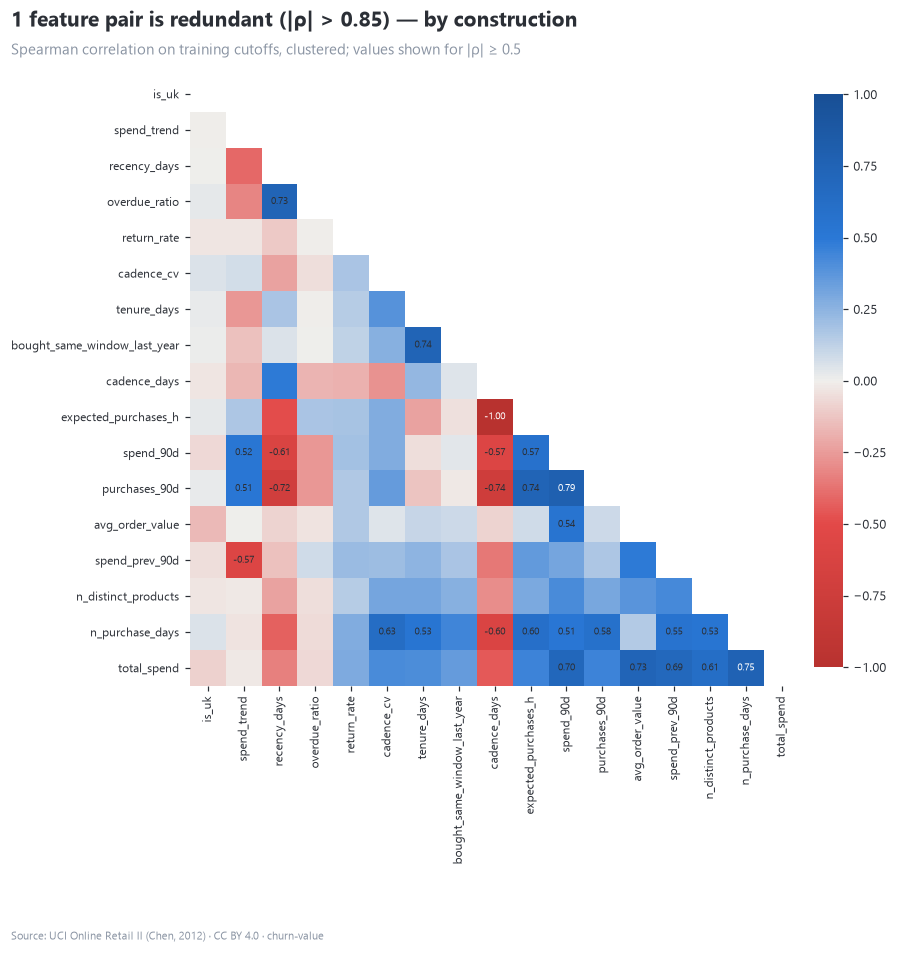

In [6]:
corr = train[BASE_FEATURES + DERIVED_FEATURES].corr(method="spearman")
order = hierarchy.leaves_list(hierarchy.linkage(1 - corr.abs(), method="average"))
corr = corr.iloc[order, order]
mask = np.triu(np.ones_like(corr, dtype=bool))
pairs = [
    (a, b, corr.loc[a, b])
    for i, a in enumerate(corr.index)
    for b in corr.index[:i]
    if abs(corr.loc[a, b]) > 0.85
]
S["redundant_pairs"] = [{"a": a, "b": b, "rho": r} for a, b, r in pairs]

fig, ax = plt.subplots(figsize=(8.4, 7.2))
im = ax.imshow(np.ma.masked_array(corr.to_numpy(), mask), cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.index, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(len(corr)):
    for j in range(i):
        v = corr.iloc[i, j]
        if abs(v) >= 0.5:
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=6.5,
                color="white" if abs(v) > 0.75 else INK,
            )
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.outline.set_visible(False)
n_pairs = f"{len(pairs)} feature pair{'s are' if len(pairs) != 1 else ' is'}"
style.headline(
    fig,
    f"{n_pairs} redundant (|ρ| > 0.85) — by construction",
    "Spearman correlation on training cutoffs, clustered; values shown for |ρ| ≥ 0.5",
)
style.add_source(fig, y=-0.2)  # below the rotated tick labels
save(fig, "correlation")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">F6 · The season</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">features that let a model know *when* it is predicting</span></div>

Stage 04 showed that the churn base rate follows the calendar. A model trained on a mix of
cutoffs can only reproduce that if it knows the cutoff's position in the year — hence the two
context features (month on the unit circle, so December sits next to January) — and whether the
customer bought in the *same season last year*, available from December 2010 onwards.

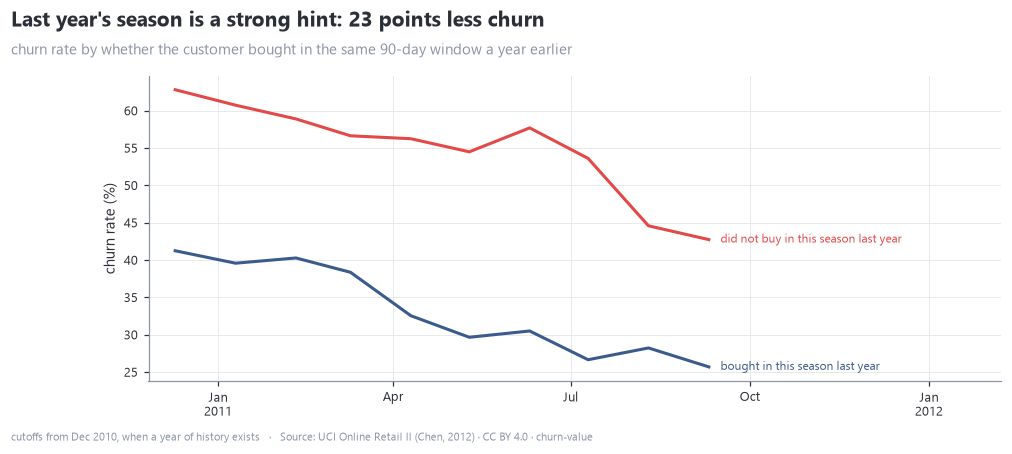

In [7]:
seasonal = snapshots[snapshots["cutoff"] >= pd.Timestamp("2010-12-10")]
by_flag = seasonal.groupby(["cutoff", "bought_same_window_last_year"])["churn"].mean().unstack()
S["churn_by_same_window_flag"] = {
    "bought_last_year": seasonal.loc[seasonal["bought_same_window_last_year"] == 1, "churn"].mean(),
    "did_not": seasonal.loc[seasonal["bought_same_window_last_year"] == 0, "churn"].mean(),
}
S["same_window_flag_share"] = seasonal["bought_same_window_last_year"].mean()

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(by_flag.index, by_flag[0] * 100, color=CHURN, lw=2)
ax.plot(by_flag.index, by_flag[1] * 100, color=NEUTRAL, lw=2)
ax.text(
    by_flag.index[-1] + pd.Timedelta(days=6),
    by_flag[0].iloc[-1] * 100,
    "did not buy in this season last year",
    va="center",
    fontsize=8,
    color=CHURN,
)
ax.text(
    by_flag.index[-1] + pd.Timedelta(days=6),
    by_flag[1].iloc[-1] * 100,
    "bought in this season last year",
    va="center",
    fontsize=8,
    color=NEUTRAL,
)
ax.set_xlim(None, by_flag.index[-1] + pd.Timedelta(days=150))
ax.set_ylabel("churn rate (%)")
style.date_axis(ax)
flag = S["churn_by_same_window_flag"]
gap = flag["did_not"] - flag["bought_last_year"]
style.headline(
    fig,
    f"Last year's season is a strong hint: {gap * 100:.0f} points less churn",
    "churn rate by whether the customer bought in the same 90-day window a year earlier",
)
style.add_source(fig, "cutoffs from Dec 2010, when a year of history exists")
save(fig, "season")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">05 → 06, 07</span></div>

**Produced** — `reports/results/05_summary.json` and the figures `05_distributions`,
`05_effect_sizes`, `05_correlation`, `05_season`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>The leakage guard holds on real data: scrambling every post-cutoff transaction changes no feature of any customer.</li><li>Purchase frequency (and its twins, cadence and expected purchases) separates the classes most (|δ| ≈ 0.40), then recent spend and activity (≈ 0.30–0.37); lateness relative to cadence is negligible inside the eligible population, as stage 04 predicted.</li><li>Where a year of history exists, buying in the same season last year cuts churn from 56 % to 33 %. Its δ over all training cutoffs is diluted (−0.08) because the flag is structurally 0 before December 2010 — a reminder that effect sizes are context, not a selection rule.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>13 base, 4 derived and 2 context features, all computed strictly on or before the cutoff; no label-guided selection.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>07_model_training</b> — the logistic model drops <code>expected_purchases_h</code> (a transform of cadence) and is regularised; tree models use all 19 features.</li><li><b>09_explainability</b> — the effect sizes here are the reference to sanity-check what the model relies on.</li></ul></div>

In [8]:
S.write(RESULTS)

WindowsPath('reports/results/05_summary.json')